# 📈 AI Student Success & Behaviour Analytics System

## Machine Learning Project

### Developed By:
Ankit Chowdhary

---

## Project Objectives

This project aims to:

- Predict student academic performance
- Predict dropout/pass risk
- Analyze student feedback using NLP
- Group students based on performance and behavior
- Detect unusual student patterns
- Reduce dimensions using PCA
- Compare machine learning models

---

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit

---

## Dataset Used

- Student Performance Dataset
- Custom Student Feedback Dataset

# 📉SIMPLE LINEAR REGRESSION (SLR)

## Objective

Predict student exam score using study hours.

---

## Concepts Covered

- Introduction to Machine Learning
- Regression Line
- Best Fit Line
- Assumptions of SLR
- Hypothesis Testing
- Residual Analysis
- Predictions
- Linear Regression using sklearn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

##  📥 Loading the student dataset into a pandas DataFrame.


In [2]:
df = pd.read_csv("../data/StudentsPerformance.csv")


## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 📊 Displaying the dataset shape (rows and columns).


In [4]:
print(df.shape)

(1000, 8)


## ℹ️ Checking data types and missing values in the dataset.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## 🔎 Showing summary statistics for numeric columns.


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## 🚨 Counting missing values in each column.


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

## 🎲 Setting the random seed to make results repeatable.


In [8]:
np.random.seed(42)

df['study_hours'] = np.random.randint(1, 10, size=len(df))

## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


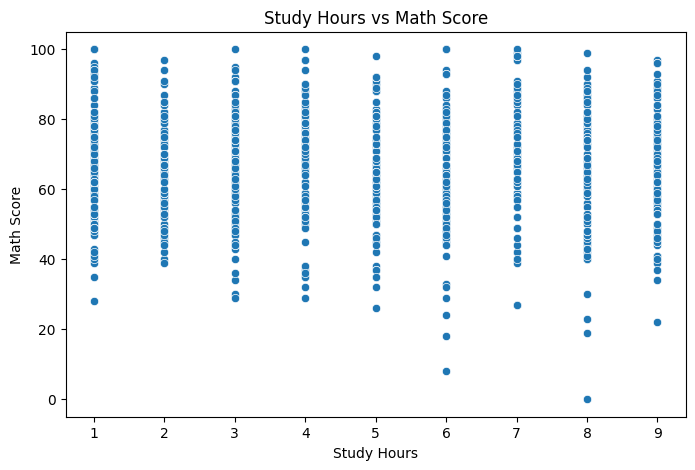

In [9]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['study_hours'],
    y=df['math score']
)

plt.title("Study Hours vs Math Score")
plt.xlabel("Study Hours")
plt.ylabel("Math Score")

plt.show()

##  🧮 Selecting the feature and target columns for model training.


In [10]:
X = df[['study_hours']]
y = df['math score']

## ✂️ Splitting data into training and testing sets for model evaluation.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 🤖 Training a linear regression model on the data.


In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

## 🧾 Executing the next step of the student analytics workflow.


In [13]:
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_)

Intercept: 66.7527821776553
Coefficient: [-0.0523936]


## 🔮 Using the trained model to make predictions.


In [14]:
y_pred = model.predict(X_test)

## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


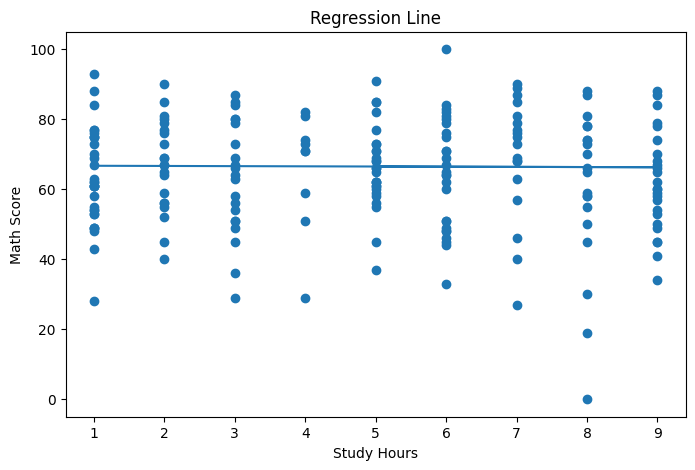

In [15]:
plt.figure(figsize=(8,5))

plt.scatter(X_test, y_test)

plt.plot(X_test, y_pred)

plt.xlabel("Study Hours")
plt.ylabel("Math Score")

plt.title("Regression Line")

plt.show()

## 📐 Calculating residuals to measure prediction errors.


In [16]:
residuals = y_test - y_pred

## 📐 Calculating residuals to measure prediction errors.


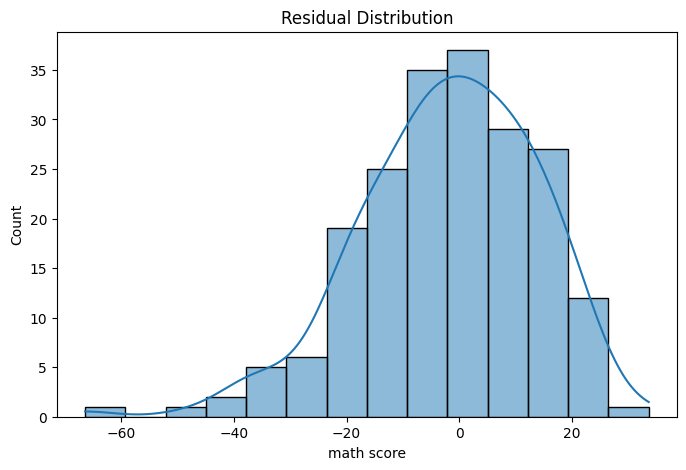

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

## 📏 Calculating the model error to check prediction accuracy.


In [18]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 12.339370598534483
MSE: 247.37663526386044
RMSE: 15.728211445166307
R2 Score: -0.016595141843048333


# 📊MULTIPLE LINEAR REGRESSION (MLR)

## Objective

Predict student math score using multiple features.

---

## Concepts Covered

- Multiple Linear Regression
- Categorical Variables
- Feature Encoding
- Correlation Analysis
- Multicollinearity
- Feature Selection
- Recursive Feature Elimination (RFE)
- Residual Analysis
- Predictions
- Model Evaluation

In [19]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,study_hours
0,female,group B,bachelor's degree,standard,none,72,72,74,7
1,female,group C,some college,standard,completed,69,90,88,4
2,female,group B,master's degree,standard,none,90,95,93,8
3,male,group A,associate's degree,free/reduced,none,47,57,44,5
4,male,group C,some college,standard,none,76,78,75,7


## 🧾 Executing the next step of the student analytics workflow.


In [20]:
mlr_df = df.copy()

## 🧾 Executing the next step of the student analytics workflow.


In [21]:
X = mlr_df[[
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course',
    'reading score',
    'writing score',
    'study_hours'
]]

y = mlr_df['math score']

## 🔧 Converting categorical columns into numeric values for the model.


In [22]:
X = pd.get_dummies(X, drop_first=True)

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [23]:
X.head()

,reading score,writing score,study_hours,gender_male,race/ethnicity_group B,race/ethnicity_group C,race/ethnicity_group D,race/ethnicity_group E,parental level of education_bachelor's degree,parental level of education_high school,parental level of education_master's degree,parental level of education_some college,parental level of education_some high school,lunch_standard,test preparation course_none
0,72,74,7,False,True,False,False,False,True,False,False,False,False,True,True
1,90,88,4,False,False,True,False,False,False,False,False,True,False,True,False
2,95,93,8,False,True,False,False,False,False,False,True,False,False,True,True
3,57,44,5,True,False,False,False,False,False,False,False,False,False,False,True
4,78,75,7,True,False,True,False,False,False,False,False,True,False,True,True


## 🖼️ Creating a plot to visualize the data or results.


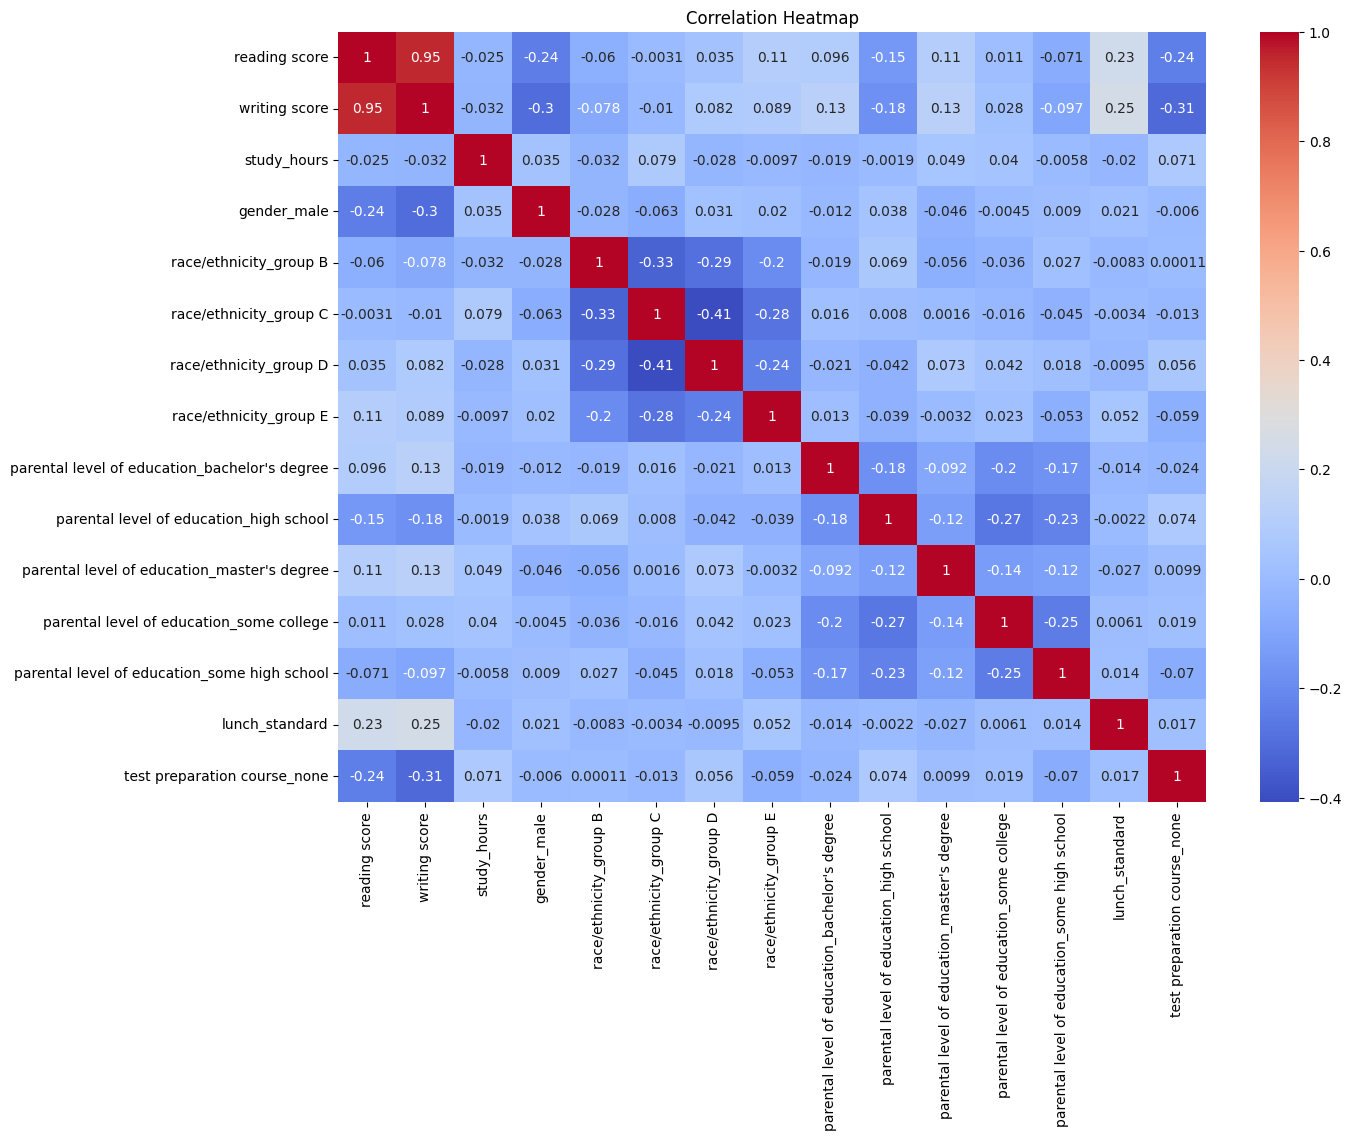

In [24]:
plt.figure(figsize=(14,10))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## ✂️ Splitting data into training and testing sets for model evaluation.


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 🤖 Training a linear regression model on the data.


In [26]:
mlr_model = LinearRegression()

mlr_model.fit(X_train, y_train)

LinearRegression()

## 🧾 Executing the next step of the student analytics workflow.


In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': mlr_model.coef_
})

coefficients

,Feature,Coefficient
0,reading score,0.236042
1,writing score,0.724076
2,study_hours,0.022472
3,gender_male,13.055153
4,race/ethnicity_group B,0.350314
5,race/ethnicity_group C,-0.646491
6,race/ethnicity_group D,-0.625572
7,race/ethnicity_group E,4.881516
8,parental level of education_bachelor's degree,-0.713802
9,parental level of education_high school,0.923617


## 🔮 Using the trained model to make predictions.


In [28]:
y_pred = mlr_model.predict(X_test)

## 📏 Calculating the model error to check prediction accuracy.


In [29]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 4.217432675035534
MSE: 29.159982501703354
RMSE: 5.399998379787105
R2 Score: 0.8801669506263567


## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


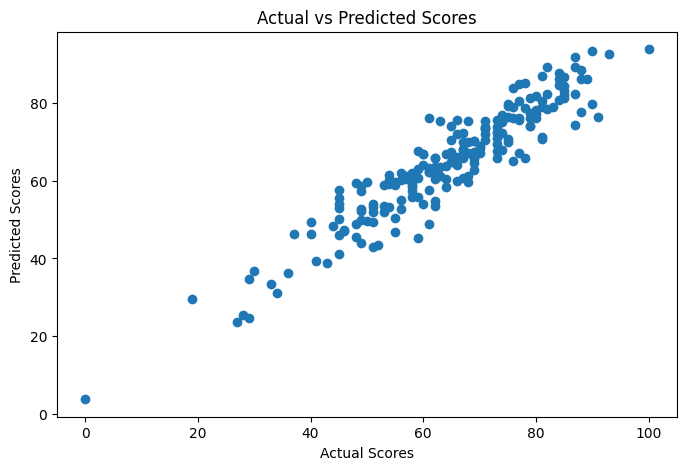

In [30]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")

plt.title("Actual vs Predicted Scores")

plt.show()

## 📐 Calculating residuals to measure prediction errors.


In [31]:
residuals = y_test - y_pred

## 📐 Calculating residuals to measure prediction errors.


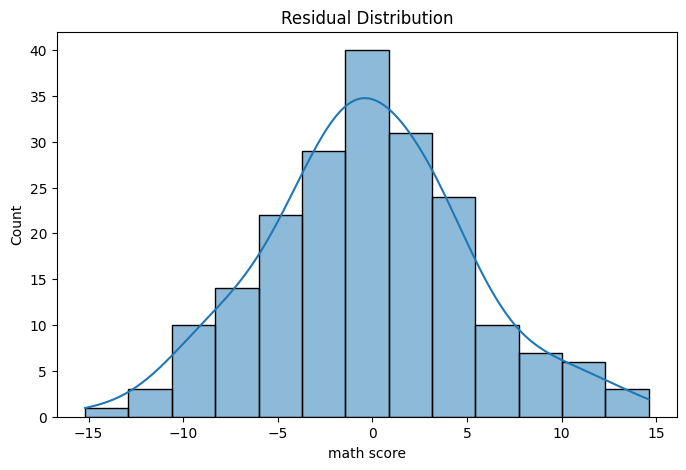

In [32]:
plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [33]:
from sklearn.feature_selection import RFE

## 🤖 Training a linear regression model on the data.


In [34]:
rfe = RFE(
    estimator=LinearRegression(),
    n_features_to_select=5
)

rfe.fit(X, y)

RFE(estimator=LinearRegression(), n_features_to_select=5)

## 🧾 Executing the next step of the student analytics workflow.


In [35]:
selected_features = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

selected_features

,Feature,Selected,Rank
0,reading score,False,8
1,writing score,False,3
2,study_hours,False,11
3,gender_male,True,1
4,race/ethnicity_group B,False,4
5,race/ethnicity_group C,False,9
6,race/ethnicity_group D,False,10
7,race/ethnicity_group E,True,1
8,parental level of education_bachelor's degree,False,2
9,parental level of education_high school,False,6


# LOGISTIC REGRESSION

## Objective

Predict whether a student will Pass or Fail using Logistic Regression.

---

## Concepts Covered

- Classification Function
- Odds and Log Odds
- Binary Variable Distribution
- Maximum Likelihood Estimation (MLE)
- Log Loss Function
- Gradient Descent
- Confusion Matrix
- Accuracy
- Sensitivity and Specificity
- ROC Curve
- Precision and Recall
- Feature Elimination using RFE

## ✅ Creating a pass/fail label from math scores.


In [36]:
df['pass'] = df['math score'].apply(
    lambda x: 1 if x >= 40 else 0
)

## 📊 Counting how many students are in each category.


In [37]:
df['pass'].value_counts()

pass
1    960
0     40
Name: count, dtype: int64

## 🖼️ Creating a plot to visualize the data or results.


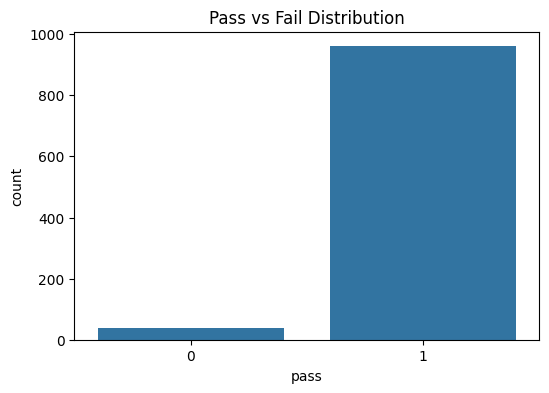

In [38]:
plt.figure(figsize=(6,4))

sns.countplot(x=df['pass'])

plt.title("Pass vs Fail Distribution")

plt.show()

## 🧮 Selecting the feature and target columns for model training.


In [39]:
X = df[[
    'reading score',
    'writing score',
    'study_hours'
]]

y = df['pass']

## ✂️ Splitting data into training and testing sets for model evaluation.


In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 📐 Scaling numeric data so features are on the same scale.


In [41]:
from sklearn.preprocessing import StandardScaler

## 📐 Scaling numeric data so features are on the same scale.


In [42]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## 🟢 Training a logistic regression model for classification.


In [43]:
from sklearn.linear_model import LogisticRegression

## 🏋️‍♂️ Fitting the model to the training data.


In [44]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

## 🔮 Using the trained model to make predictions.


In [45]:
y_pred = log_model.predict(X_test)

## 🧾 Executing the next step of the student analytics workflow.


In [46]:
y_prob = log_model.predict_proba(X_test)[:,1]

## 🧪 Evaluating the classifier with standard performance metrics.


In [47]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

## 🧪 Evaluating the classifier with standard performance metrics.


In [48]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[  6   5]
 [  1 188]]


## 🖼️ Creating a plot to visualize the data or results.


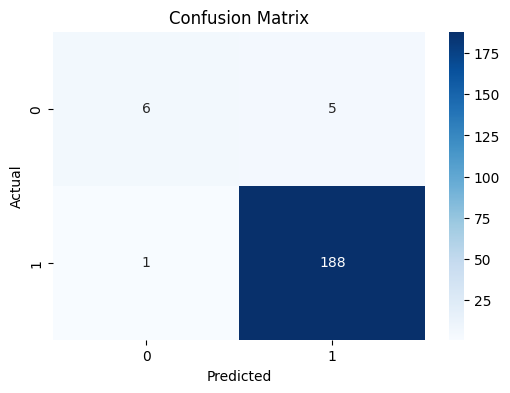

In [49]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [50]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.97


## 🧾 Executing the next step of the student analytics workflow.


In [51]:
precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.9740932642487047
Recall: 0.9947089947089947
F1 Score: 0.9842931937172775


## 🧪 Evaluating the classifier with standard performance metrics.


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.97      0.99      0.98       189

    accuracy                           0.97       200
   macro avg       0.92      0.77      0.83       200
weighted avg       0.97      0.97      0.97       200



## 📈 Plotting ROC metrics to check classifier performance.


In [53]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

## 🧾 Executing the next step of the student analytics workflow.


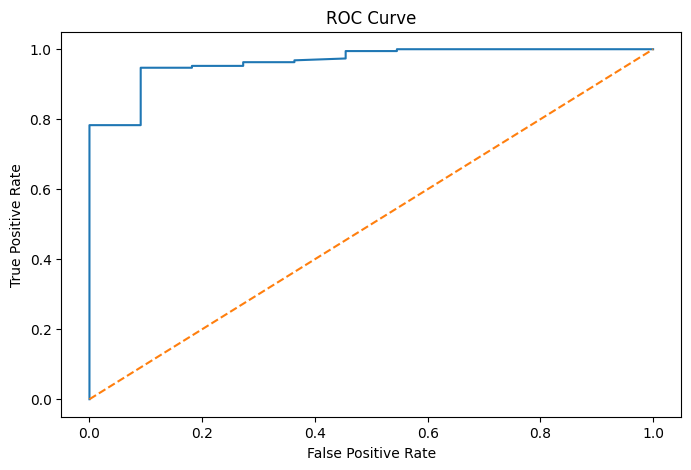

In [54]:
plt.figure(figsize=(8,5))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.show()

## 📈 Plotting ROC metrics to check classifier performance.


In [55]:
auc_score = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.9646464646464646


## 🧪 Evaluating the classifier with standard performance metrics.


In [56]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

sensitivity = tp / (tp + fn)

specificity = tn / (tn + fp)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

Sensitivity: 0.9947089947089947
Specificity: 0.5454545454545454


## ✨ Using feature selection to find the most important input columns.


In [57]:
rfe = RFE(
    estimator=LogisticRegression(),
    n_features_to_select=2
)

rfe.fit(X, y)

RFE(estimator=LogisticRegression(), n_features_to_select=2)

## 🧾 Executing the next step of the student analytics workflow.


In [58]:
selected_features = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
})

selected_features

,Feature,Selected,Rank
0,reading score,False,2
1,writing score,True,1
2,study_hours,True,1


# UNIT IV — NAIVE BAYES

## Objective

Analyze student feedback and classify it as Positive or Negative using Naive Bayes.

---

## Concepts Covered

- Conditional Probability
- Bayes Theorem
- Text Classification
- Laplace Smoothing
- Bernoulli Naive Bayes
- Multinomial Naive Bayes
- Text Preprocessing
- CountVectorizer
- TF-IDF

## 💬 Creating or loading student feedback data for text analysis.


In [59]:
feedback_data = {
    'feedback': [
        "The faculty is very supportive",
        "Classes are boring",
        "Teachers explain concepts clearly",
        "Assignments are stressful",
        "The labs are excellent",
        "The syllabus is too difficult",
        "Very good learning environment",
        "The management is poor",
        "Excellent teaching methods",
        "Too much academic pressure",
        "Helpful teachers and staff",
        "Lack of practical sessions"
    ],
    
    'sentiment': [
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative",
        "positive",
        "negative"
    ]
}

## 💬 Creating or loading student feedback data for text analysis.


In [60]:
feedback_df = pd.DataFrame(feedback_data)

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [61]:
feedback_df.head()

,feedback,sentiment
0,The faculty is very supportive,positive
1,Classes are boring,negative
2,Teachers explain concepts clearly,positive
3,Assignments are stressful,negative
4,The labs are excellent,positive


## 🧠 Importing the libraries needed for data analysis, plotting, and machine learning.


In [62]:
import nltk
import string

from nltk.corpus import stopwords

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.naive_bayes import BernoulliNB

## 📥 Downloading text processing resources for natural language processing.


In [63]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ankitchowdhary/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 🧼 Defining a text cleaning function to prepare feedback for analysis.


In [64]:
def clean_text(text):
    
    text = text.lower()
    
    text = ''.join(
        char for char in text
        if char not in string.punctuation
    )
    
    words = text.split()
    
    words = [
        word for word in words
        if word not in stopwords.words('english')
    ]
    
    return ' '.join(words)

## 💬 Creating or loading student feedback data for text analysis.


In [65]:
feedback_df['cleaned_feedback'] = feedback_df['feedback'].apply(clean_text)

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [66]:
feedback_df.head()

,feedback,sentiment,cleaned_feedback
0,The faculty is very supportive,positive,faculty supportive
1,Classes are boring,negative,classes boring
2,Teachers explain concepts clearly,positive,teachers explain concepts clearly
3,Assignments are stressful,negative,assignments stressful
4,The labs are excellent,positive,labs excellent


## 💬 Creating or loading student feedback data for text analysis.


In [67]:
X = feedback_df['cleaned_feedback']

y = feedback_df['sentiment']

## 🧾 Executing the next step of the student analytics workflow.


In [68]:
cv = CountVectorizer()

X_cv = cv.fit_transform(X)

## ✂️ Splitting data into training and testing sets for model evaluation.


In [69]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cv,
    y,
    test_size=0.2,
    random_state=42
)

## 🧾 Executing the next step of the student analytics workflow.


In [70]:
multi_nb = MultinomialNB()

multi_nb.fit(X_train, y_train)

MultinomialNB()

## 🔮 Using the trained model to make predictions.


In [71]:
y_pred_multi = multi_nb.predict(X_test)

## 🧾 Executing the next step of the student analytics workflow.


In [72]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_multi))

Accuracy: 0.6666666666666666


## 🧪 Evaluating the classifier with standard performance metrics.


In [73]:
print(classification_report(
    y_test,
    y_pred_multi
))

              precision    recall  f1-score   support

    negative       0.50      1.00      0.67         1
    positive       1.00      0.50      0.67         2

    accuracy                           0.67         3
   macro avg       0.75      0.75      0.67         3
weighted avg       0.83      0.67      0.67         3



## 🖼️ Creating a plot to visualize the data or results.


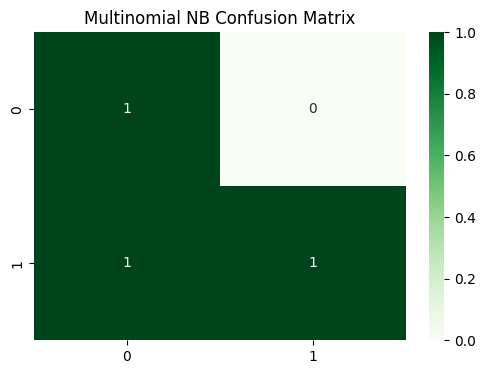

In [74]:
cm = confusion_matrix(y_test, y_pred_multi)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Multinomial NB Confusion Matrix")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [75]:
bnb = BernoulliNB()

bnb.fit(X_train, y_train)

BernoulliNB()

## 🔮 Using the trained model to make predictions.


In [76]:
y_pred_bnb = bnb.predict(X_test)

## 🧾 Executing the next step of the student analytics workflow.


In [77]:
print("Accuracy:",
      accuracy_score(y_test, y_pred_bnb))

Accuracy: 0.3333333333333333


## 🧪 Evaluating the classifier with standard performance metrics.


In [78]:
print(classification_report(
    y_test,
    y_pred_bnb
))

              precision    recall  f1-score   support

    negative       0.33      1.00      0.50         1
    positive       0.00      0.00      0.00         2

    accuracy                           0.33         3
   macro avg       0.17      0.50      0.25         3
weighted avg       0.11      0.33      0.17         3



## 🧾 Executing the next step of the student analytics workflow.


In [79]:
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(X)

## 🧾 Executing the next step of the student analytics workflow.


In [80]:
custom_feedback = [
    "Teachers are very helpful"
]

## 🔮 Using the trained model to make predictions.


In [81]:
custom_vector = cv.transform(custom_feedback)

prediction = multi_nb.predict(custom_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: positive


## ☁️ Creating a word cloud to visualize the most common feedback words.


In [82]:
from wordcloud import WordCloud

## 🖼️ Creating a plot to visualize the data or results.


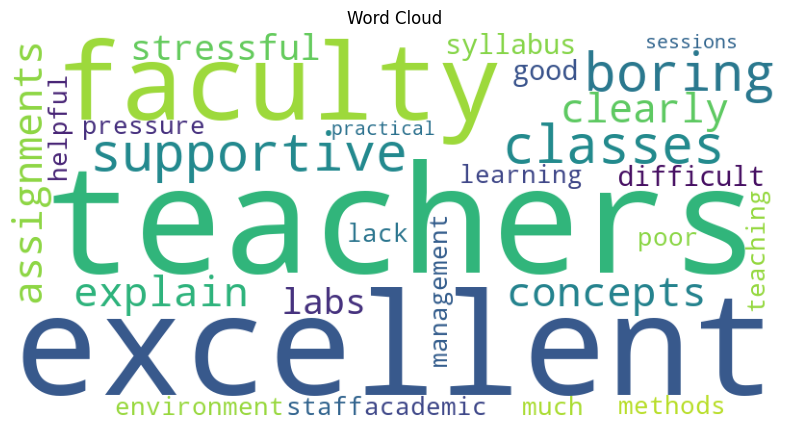

In [83]:
text = ' '.join(feedback_df['cleaned_feedback'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis('off')

plt.title("Word Cloud")

plt.show()

# UNIT V — K-MEANS CLUSTERING

## Objective

Group students based on their academic performance and behavior.

---

## Concepts Covered

- Clustering
- Segmentation
- Distance Measures
- Hopkins Statistics
- K-Means Algorithm
- KMeans++
- Elbow Method
- Optimal Number of Clusters
- Cluster Analysis

## 📐 Scaling numeric data so features are on the same scale.


In [84]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 🧾 Executing the next step of the student analytics workflow.


In [85]:
cluster_df = df[[
    'math score',
    'reading score',
    'writing score',
    'study_hours'
]]

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [86]:
cluster_df.head()

,math score,reading score,writing score,study_hours
0,72,72,74,7
1,69,90,88,4
2,90,95,93,8
3,47,57,44,5
4,76,78,75,7


## 📐 Scaling numeric data so features are on the same scale.


In [87]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(cluster_df)

## 🧾 Executing the next step of the student analytics workflow.


In [88]:
wcss = []

## 🧾 Executing the next step of the student analytics workflow.


In [89]:
for i in range(1, 11):
    
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42
    )
    
    kmeans.fit(scaled_data)
    
    wcss.append(kmeans.inertia_)

## 🧾 Executing the next step of the student analytics workflow.


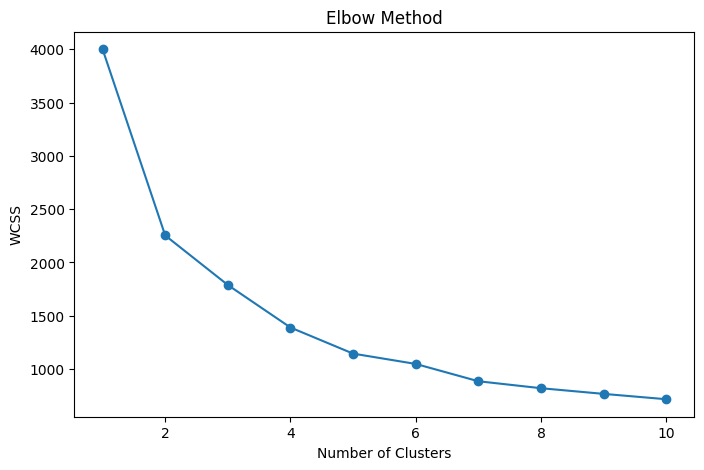

In [90]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [91]:
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    random_state=42
)

## 🔮 Using the trained model to make predictions.


In [92]:
clusters = kmeans.fit_predict(scaled_data)

## 🧾 Executing the next step of the student analytics workflow.


In [93]:
cluster_df['Cluster'] = clusters

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [94]:
cluster_df.head()

,math score,reading score,writing score,study_hours,Cluster
0,72,72,74,7,0
1,69,90,88,4,2
2,90,95,93,8,2
3,47,57,44,5,1
4,76,78,75,7,2


## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


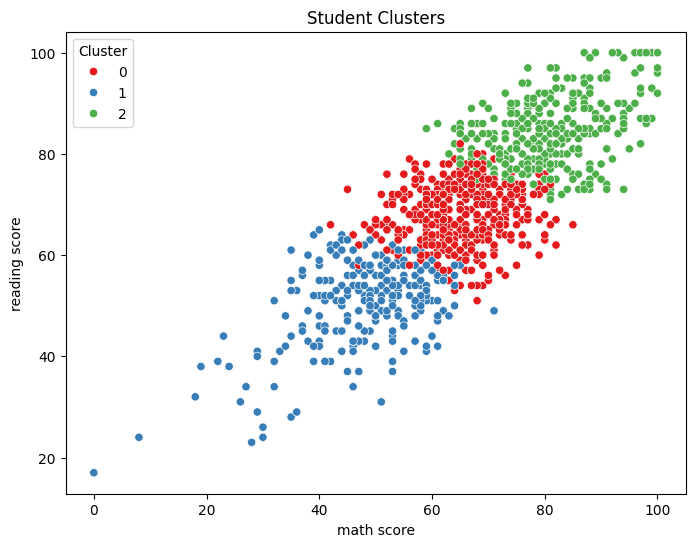

In [95]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['math score'],
    y=cluster_df['reading score'],
    hue=cluster_df['Cluster'],
    palette='Set1'
)

plt.title("Student Clusters")

plt.show()

## 📊 Counting how many students are in each category.


In [96]:
cluster_df['Cluster'].value_counts()

Cluster
0    431
2    326
1    243
Name: count, dtype: int64

## 🧾 Executing the next step of the student analytics workflow.


In [97]:
cluster_analysis = cluster_df.groupby('Cluster').mean()

cluster_analysis

,math score,reading score,writing score,study_hours
Cluster,,,,
0,64.986079,67.955916,67.322506,5.025522
1,47.818930,50.510288,48.267490,4.876543
2,81.165644,84.680982,83.769939,4.745399


# ADVANCED ANALYTICS

## Objective

Perform advanced clustering, anomaly detection, dimensionality reduction, and automated model comparison.

---

## Concepts Covered

- Hierarchical Clustering
- Dendrogram
- Linkage Methods
- DBSCAN
- Silhouette Score
- PCA
- AutoML
- Model Suggestion using GenAI

## 🌳 Running hierarchical clustering to see student group structure.


In [98]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import fcluster

from sklearn.cluster import AgglomerativeClustering

## 🧾 Executing the next step of the student analytics workflow.


In [99]:
linked = linkage(
    scaled_data,
    method='ward'
)

## 🌳 Running hierarchical clustering to see student group structure.


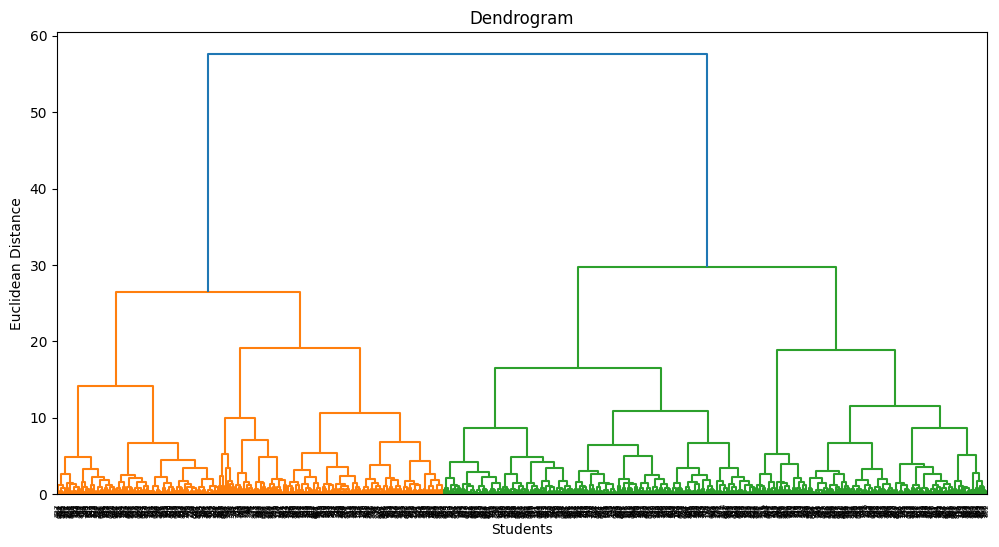

In [100]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Students")

plt.ylabel("Euclidean Distance")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [101]:
hc = AgglomerativeClustering(
    n_clusters=3
)

## 🔮 Using the trained model to make predictions.


In [102]:
hc_labels = hc.fit_predict(scaled_data)

## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


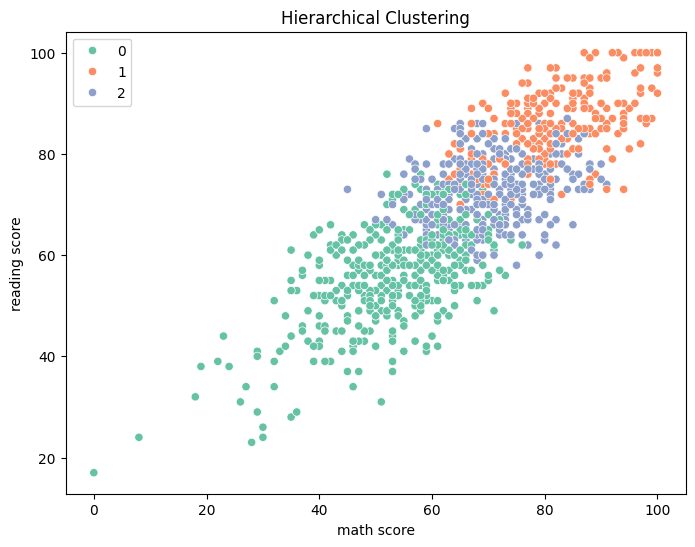

In [103]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['math score'],
    y=cluster_df['reading score'],
    hue=hc_labels,
    palette='Set2'
)

plt.title("Hierarchical Clustering")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [104]:
from sklearn.cluster import DBSCAN

## 🧾 Executing the next step of the student analytics workflow.


In [105]:
dbscan = DBSCAN(
    eps=1.2,
    min_samples=5
)

## 🔮 Using the trained model to make predictions.


In [106]:
dbscan_labels = dbscan.fit_predict(scaled_data)

## 🧾 Executing the next step of the student analytics workflow.


In [107]:
cluster_df['DBSCAN_Cluster'] = dbscan_labels

## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


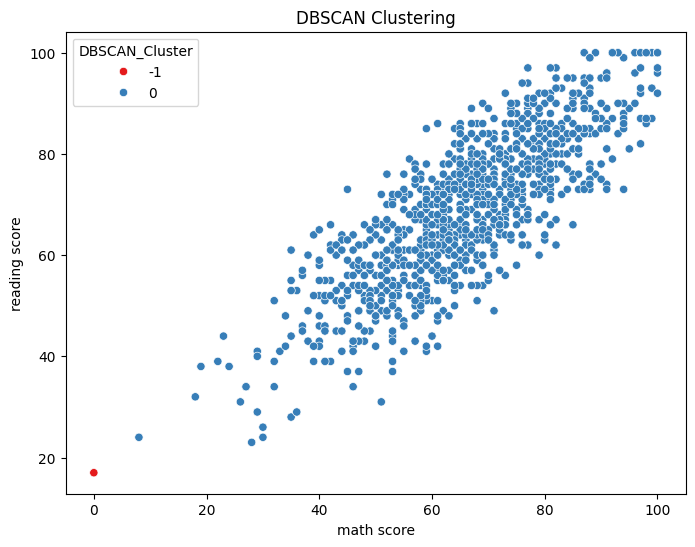

In [108]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=cluster_df['math score'],
    y=cluster_df['reading score'],
    hue=cluster_df['DBSCAN_Cluster'],
    palette='Set1'
)

plt.title("DBSCAN Clustering")

plt.show()

## 👀 Showing the first few rows of the dataset to inspect it quickly.


In [109]:
outliers = cluster_df[
    cluster_df['DBSCAN_Cluster'] == -1
]

outliers.head()

,math score,reading score,writing score,study_hours,Cluster,DBSCAN_Cluster
59,0,17,10,8,1,-1


## 📏 Calculating silhouette score to measure cluster quality.


In [110]:
from sklearn.metrics import silhouette_score

## 📏 Calculating silhouette score to measure cluster quality.


In [111]:
sil_score = silhouette_score(
    scaled_data,
    clusters
)

print("Silhouette Score:", sil_score)

Silhouette Score: 0.2616213350951654


## 🧾 Executing the next step of the student analytics workflow.


In [112]:
from sklearn.decomposition import PCA

## 🧾 Executing the next step of the student analytics workflow.


In [113]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

## 🧾 Executing the next step of the student analytics workflow.


In [114]:
pca_df = pd.DataFrame(
    data=pca_data,
    columns=['PC1', 'PC2']
)

## 📉 Drawing a scatter plot to see the relationship between study hours and math score.


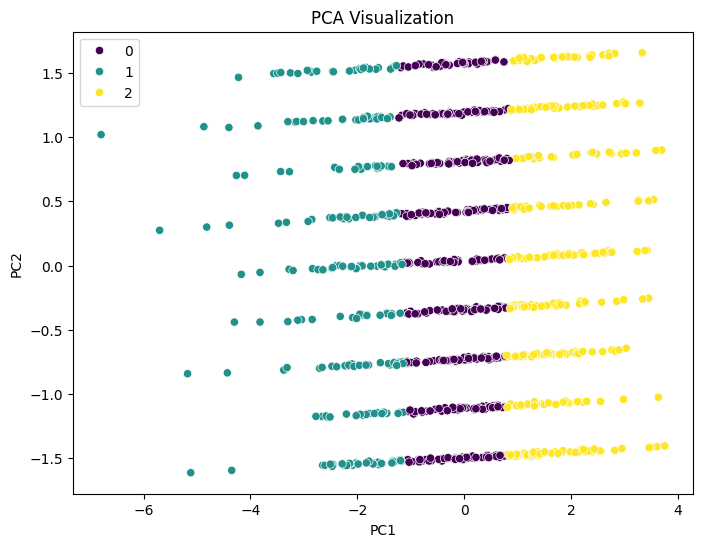

In [115]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=pca_df['PC1'],
    y=pca_df['PC2'],
    hue=clusters,
    palette='viridis'
)

plt.title("PCA Visualization")

plt.show()

## 🧾 Executing the next step of the student analytics workflow.


In [116]:
print(
    pca.explained_variance_ratio_
)

[0.67985389 0.24980363]


## 🧾 Executing the next step of the student analytics workflow.


In [117]:
from lazypredict.Supervised import LazyClassifier

## 🧮 Selecting the feature and target columns for model training.


In [118]:
X = df[[
    'reading score',
    'writing score',
    'study_hours'
]]

y = df['pass']

## ✂️ Splitting data into training and testing sets for model evaluation.


In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## 🧾 Executing the next step of the student analytics workflow.


In [120]:
clf = LazyClassifier(verbose=0)

models, predictions = clf.fit(
    X_train,
    X_test,
    y_train,
    y_test
)

# 🧾 Executing the next step of the student analytics workflow.


In [121]:
models

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,Precision,Recall,Time Taken
Model,,,,,,,
GaussianNB,0.955,0.890572,0.967532,0.958865,0.965666,0.955,0.008687
Perceptron,0.915,0.869408,0.953102,0.929272,0.954886,0.915,0.013309
NearestCentroid,0.815,0.859307,0.966570,0.862359,0.950820,0.815,0.020183
SGDClassifier,0.945,0.842472,0.966089,0.949724,0.957092,0.945,0.010979
RandomForestClassifier,0.965,0.810245,0.930255,0.964213,0.963605,0.965,0.155526
ExtraTreesClassifier,0.965,0.810245,0.880471,0.964213,0.963605,0.965,0.074852
BaggingClassifier,0.960,0.807600,0.886724,0.960000,0.960000,0.960,0.029986
LabelPropagation,0.955,0.804954,0.967051,0.955919,0.956977,0.955,0.075124
PassiveAggressiveClassifier,0.955,0.804954,0.967051,0.955919,0.956977,0.955,0.020263
